In [1]:
cd ..

/share/gpu0/mars/src_aiai


In [2]:
import tqdm
import sparse
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.metrics import structural_similarity, peak_signal_noise_ratio, mean_squared_error
from scipy.fft import fft, ifft, fftfreq, fftshift
from functools import partial
from scipy.interpolate import interp1d

from src.operators.NUFFT2D import NUFFT2D
from src.sampling.uv_sampling import random_sampling, spider_sampling

In [3]:
from  scipy.special import iv

def calculate_kaiser_bessel_coef_1d(k, i, Jd=(6)):
    """Calculate the Kaiser-Bessel kernel coefficients for a 1d grid for the neighbouring pixels. 

    Args:
        k (float,float): location of the point to be interpolated
        i (int): extra index parameter
        Jd (tuple, optional): Amount of neibhouring pixels to be used in each direction. Defaults to (6,6).

    Returns:
        indices (list): list of indices of all the calculated coefficients
        values (list): list of the calculated coefficients
    
    TODO integrate this function with its 2d variant. 
    """

    k = k.reshape(-1,1)
    J = Jd[0]//2
    a = np.array(np.meshgrid(*[range(-J, J) for i in range(k.shape[0])])).reshape(k.shape[0], -1)
    a += (k % 1 >0.5) # corrects to the closest 6 pixels
    indices = (k.astype(int) + a)
    J = Jd[0] # assuming same pixel sensitivity in all directions

    beta = 2.34*J
    norm = J 

    # for 2d do the interpolation 2 times, once in each direction
    u =  k - indices
    values = 1
    for j in range(k.shape[0]):
        values *= iv(0, beta*np.sqrt(1 +0j - (2*u[j]/Jd[j])**2)).real / Jd[j]

    indices = np.vstack((
            np.zeros(indices.shape[1]), # empty axis
            np.repeat(i, indices.shape[1]), # filter axis
            indices, # )
#             indices[1]) 
    )).astype(int)

    return indices.T, values

In [4]:
class NUFFT_op_1D():
    """NUFFT implementation using a Kaiser-Bessel kernel for interpolation. 
    """
    def __init__(self):
        pass
        # TODO generalise more, (pick axes, norm, etc.)
        
    def plan(self, uv, Nd, Kd, Jd, batch_size=None):
        # saving some values
        self.Nd = Nd
        self.Kd = Kd
        self.Jd = Jd
        self.M = len(uv)
        
        if uv.ndim < 2:
            uv = uv[:,np.newaxis]
        
        gridsize = 2*np.pi / Kd[0]
        k = (uv + np.pi) / gridsize
        print(k.shape)
        # calculating coefficients for interpolation
        indices = []
        values =  []
        for i in tqdm.tqdm(range(len(uv))):
            ind, vals = calculate_kaiser_bessel_coef_1d(k[i], i, Jd)
            indices.append(ind)
            values.append(vals.real)
        
        # building sparse matrix
        indices = np.array(indices).reshape(-1, uv.shape[1] +2)
        values = np.array(values).reshape(-1)
        self.interp_matrix = sparse.COO(indices.T, values, shape=[1, len(uv)] + list(Kd) )

        # calculating scaling based on iFT of the KB kernel
        J = Jd[0] 
        beta = 2.34*J
        s_kb = lambda x: np.sinc(np.sqrt((np.pi *x *J)**2 - (2.34*J)**2 +0j)/np.pi)

        # scaling done for both axes seperately
        xx = (np.arange(Kd[0])/Kd[0] -.5)[Kd[0]//4:-Kd[0]//4]
        sa = s_kb(xx).real
        self.scaling = sa # (sa.reshape(-1,1) * sa.reshape(1,-1))
    
    def dir_op(self, xx):
        return np.squeeze(self._kk2k(self._xx2kk(self._pad((xx/self.scaling).reshape(-1, self.Nd[0])))))  # why divide on both sides?

    
    def adj_op(self, k):
        kk = self._k2kk(k)
        xx = self._kk2xx(kk)
        xx = self._unpad(xx)
        xx = np.squeeze(xx) / self.scaling
        return xx
        # return np.squeeze(self._unpad(self._kk2xx(self._k2kk(k)))) / self.scaling
    
    def _kk2k(self, kk):
        """interpolates of the grid to non uniform measurements"""
        return (self.interp_matrix * kk.reshape(-1, 1, self.Kd[0])).sum(axis=(2)).todense()
    
    def _k2kk(self, y):
        """convolutes measurements to oversampled fft grid"""
        return (self.interp_matrix * y.reshape(-1, self.M, 1)).sum(axis=1).todense()
    
    @staticmethod
    def _kk2xx(kk):
        """from 2d fourier space to 2d image space"""
        return np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(kk, axes=(-1)), norm='ortho'), axes=(-1))

    @staticmethod
    def _xx2kk(xx):
        """from 2d fourier space to 2d image space"""
        return np.fft.fftshift(np.fft.fft(np.fft.fftshift(xx, axes=(-1)), norm='ortho'), axes=(-1))
    
    def _pad(self, x):
        """pads x to go from Nd to Kd"""
        return np.pad(x, (
            ( 0,0 ),
            ( (self.Kd[0]-self.Nd[0])//2, (self.Kd[0]-self.Nd[0])//2),
            ))
    
    
    def _unpad(self, x):
        """unpads x to go from  Kd to Nd"""
        return x[
            :,
            (self.Kd[0]-self.Nd[0])//2: (self.Kd[0]-self.Nd[0])//2 +self.Nd[0],
            ] # remove zero padding from image

In [5]:
class NURADON():
    def __init__(self):
        pass
    
    def plan(self, uv, n_spokes, Nd, Kd, Jd, batch_size=None):
        """uv is of 1 spoke"""
        self.Nd = Nd
        self.Kd = Kd
        self.nufft_1d = NUFFT_op_1D()
        self.nufft_1d.plan(uv, Nd[:1], Kd[:1], Jd[:1], batch_size=None)
        self.n_spokes = n_spokes
    
    
    def dir_op(self, x):
        
        rad = radon(x, theta=np.linspace(0, 360, self.n_spokes, endpoint=False), circle=False, preserve_range=False)# N, M
        print(rad.shape)
        x_spokes = self.nufft_1d.dir_op(rad.T) # takes M, N
        return x_spokes /np.sqrt(x_spokes.shape[1])

    def adj_op(self, y):
        x_spokes = self.nufft_1d.adj_op(y)
        print(x_spokes.dtype)
        rec = iradon(x_spokes.T.real, theta=np.linspace(0, 360, self.n_spokes, endpoint=False), circle=False, preserve_range=True, filter_name=None, output_size=self.Nd[0])   
        print(rec.dtype)
        return rec / (np.pi / (2 * self.n_spokes)) / np.sqrt(2*self.Nd[0])
    
    
    def alt_adj_op(self, y, circle=False):
        theta = np.linspace(0, 360, self.n_spokes, endpoint=False)     
        radon_filtered =  np.real( self.nufft_1d.adj_op(y.reshape(n_spokes, -1)).T)

        reconstructed = np.zeros((self.Nd[0], self.Nd[1]), dtype=np.complex128)
        radius = self.Nd[0] // 2
        xpr, ypr = np.mgrid[:self.Nd[0], :self.Nd[0]] - radius
        x = np.arange(self.Nd[0]) - self.Nd[0] // 2

        for col, angle in zip(radon_filtered.T, np.deg2rad(theta)):
            t = ypr * np.cos(angle) - xpr * np.sin(angle)
            interpolant = partial(np.interp, xp=x, fp=col, left=0, right=0)
            reconstructed += interpolant(t)

        if circle:
            out_reconstruction_circle = (xpr ** 2 + ypr ** 2) > radius ** 2
            reconstructed[out_reconstruction_circle] = 0.

        return reconstructed / np.sqrt(2*self.Nd[0]) 

In [6]:
from skimage.transform import radon, iradon

In [7]:
wavebands = np.linspace(500,900, 10) # probably need to do something slightly diffferent
object_distance = 250 #km
lenslet_diameter = 8.75 #mm
longest_baseline = 0.5 #m
n_lenslets = 24
n_PICs = 37
n_specbins = 10

uvs = spider_sampling(normalised=False)

In [8]:
x0 = 0.15
pic = x0 + np.linspace(0,0.5, n_lenslets).reshape(-1,1)
angles = np.linspace(0,2*np.pi, n_PICs, endpoint=False)

coords = np.array([ (pic*np.cos(angles).reshape(1,-1)).flatten(), (pic*np.sin(angles).reshape(1,-1)).flatten()]).T

In [9]:
sns.set_context('paper', font_scale=1.6)

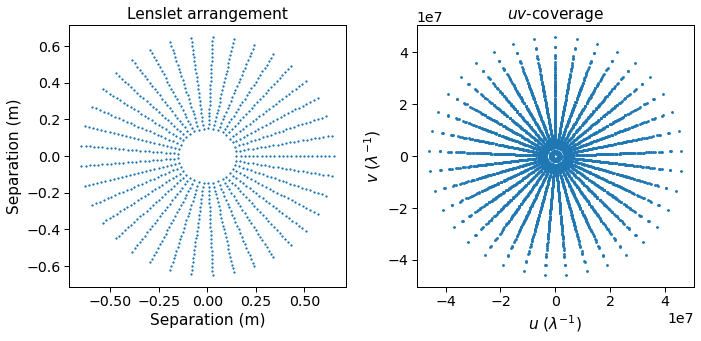

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(10,5))
ax[0].scatter(coords[:,0], coords[:,1], s=2)
ax[0].set_xlabel('Separation (m)')
ax[0].set_ylabel('Separation (m)')
ax[0].set_title('Lenslet arrangement')


ax[1].scatter(uvs[:,0], uvs[:,1], s=4)
ax[1].set_xlabel(r'$u$ $(\lambda^{-1})$')
ax[1].set_ylabel(r'$v$ $(\lambda^{-1})$')
ax[1].set_title(r'$uv$-coverage')


plt.tight_layout()
plt.savefig("./plots/spider_config.pdf", transparent = True)
# plt.subplots_adjust(wspace=0.2)

In [11]:
im = np.load("./data/intermediate/TNG/NUFFT_SPIDER/x_true_test_30dB.npy")

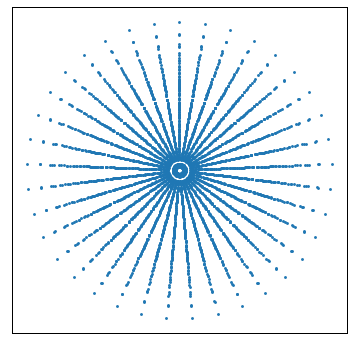

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(uvs[:,0], uvs[:,1], s=4)
plt.xticks([])
plt.yticks([])
plt.savefig("./plots/presentation_diagram_4.pdf")

In [13]:
uv = spider_sampling()

In [14]:
def dft(x, w, m):
    
    return np.array([np.sum(m * np.exp(1j*w*i)) for i in x ])/(2*len(x))

def dft2(x1, x2, w, m):
   
    w1 = np.exp(1j * w[:,0])
    w2 = np.exp(1j * w[:,1])
    N = len(x1)
    res = np.zeros((len(x1), len(x2)))
    for i in tqdm.tqdm(range(len(x1))):
        for j in range(len(x2)):
            res[i,j] = np.sum( w1**(x1[i]) * w2**(x2[j]) *m)
    return res/(2*len(x1))

In [15]:
from src.data import load_M51

In [16]:
x = load_M51()
x /= x.max()

x2 = np.load("./data/intermediate/COCO/NUFFT_SPIDER/x_true_test_30dB.npy")[4]
x2 /= x2.max()

x = x2

In [17]:
Nd = x.shape
Kd = (x.shape[0]*2, x.shape[1]*2)
Jd = (6,6)
batch_size = 1

In [18]:
n_spokes = 37
n_lenslets = 24
n_wavelengths = 10

In [19]:
uv = spider_sampling()
nufft_op = NUFFT2D()
nufft_op.plan(uv, Nd, Kd, Jd, batch_size)

100%|██████████| 4440/4440 [00:00<00:00, 5529.19it/s]


In [20]:
true = np.load(f"./data/intermediate/COCO/NUFFT_SPIDER/x_true_test_30dB.npy")


In [21]:
op_1d = NUFFT_op_1D()
uv_1d = uv[:n_lenslets//2*n_wavelengths,1] # 1 spoke has 120 measurements
op_1d.plan(uv_1d.reshape(-1,1), [Nd[0]], [Kd[0]], [6])

(120, 1)


100%|██████████| 120/120 [00:00<00:00, 13829.28it/s]


In [22]:
y2 = nufft_op.dir_op(x2)
y = nufft_op.dir_op(x)

In [23]:
x_dirty_dft = dft2(np.arange(-x.shape[0]//2,x.shape[0]//2), np.arange(-x.shape[0]//2,x.shape[0]//2), uv, y.reshape(-1))

  0%|          | 0/256 [00:00<?, ?it/s]/home/mars/.conda/envs/InterferAI/lib/python3.7/site-packages/ipykernel_launcher.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  del sys.path[0]
100%|██████████| 256/256 [01:15<00:00,  3.38it/s]


In [24]:
xx, yy = np.mgrid[:Nd[0],:Nd[0]]
circle_mask = ((xx-Nd[0]//2)**2 + (yy-Nd[0]//2)**2 < (Nd[0]//2-2)**2 ) #* ((xx-Nd[0]//2)**2 + (yy-Nd[0]//2)**2 < Nd[0]//2**2 )

In [25]:
nuradon_op  = NURADON()
nuradon_op.plan(uv_1d, n_spokes, Nd, Kd, Jd)

(120, 1)


100%|██████████| 120/120 [00:00<00:00, 10036.62it/s]


In [26]:
x_dirty_nufft = nufft_op.adj_op(y).real
x_dirty_radon = nuradon_op.adj_op(y.reshape(-1, n_lenslets//2*n_wavelengths))[::-1,::1].real

complex128
float64


In [27]:
rms = lambda x,y:  np.mean(np.square((x-y))*circle_mask)

In [28]:
ISNR = 30
sigma = np.sqrt(np.mean(np.abs(y)**2)) * 10**(-ISNR/20)
n = np.random.normal( 0, sigma, y.shape) + 1j * np.random.normal( 0, sigma, y.shape)

In [29]:
# sampling density based weighting
grid_cell = 2*np.pi /512 
binned = (uv[:,:]+np.pi+.5*grid_cell) // grid_cell
binned = [tuple(x) for x in binned]
cells = set(binned)
w_gridded = np.zeros(uv.shape[0])
for cell in list(cells):
    mask = np.all(np.array(cell) ==  binned, axis=1)
    w_gridded[mask] = np.sum(mask)

w2 = 1/w_gridded
w2 /= w2.max()

In [30]:
binned = (uv[:120,1] + np.pi+.5*grid_cell) // grid_cell
# binned = [tuple(x) for x in binned]
cells = set(binned)
w_gridded = np.zeros(120)
for cell in list(cells):
    mask = np.array(cell) ==  binned
    w_gridded[mask] = np.sum(mask)

w_1d = 1/w_gridded
w_1d = np.tile(w_1d, n_spokes)

In [31]:
w = np.linalg.norm(uv, axis=1)
w /= w.max()

In [32]:
x_dirty_nufft_ramp = nufft_op.adj_op(y*w*w_1d).real
x_dirty_nufft_dens = nufft_op.adj_op(y*w2).real 

In [48]:
mse = lambda x,y: np.mean(np.square(x-y))

In [54]:
def compare_multiple(images, ncols=None, nrows=None, titles=None, same_scale=False, colorbar=False, cmap='viridis', save_base="./plots/example", cbar_anchor=1.2, rot=0, vmin=None, vmax=None, PSNR=True):
    """[summary]
    TODO add colorbars
    Args:
        images ([type]): [description]
        ncols ([type], optional): [description]. Defaults to None.
        nrows ([type], optional): [description]. Defaults to None.
        titles ([type], optional): [description]. Defaults to None.
        same_scale (bool, optional): [description]. Defaults to False.
    """

    if not nrows:
        nrows = 1
    if not ncols:
        ncols = 1
    if ncols*nrows < len(images):
        ncols = len(images)
        nrows = 1
    if not titles:
        titles = [""]*len(images)
    
    images = [np.rot90(i, rot) for i in images]
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, 
        figsize=(ncols*6, nrows*6), squeeze=False)

    a = ax[0,0].imshow(images[0])    
    ax[0,0].set_title(titles[0])
    if vmin is None:
        vmin, vmax = a.get_clim()
    for i in range(0, nrows):
        for j in range(ncols):
            if i +j*nrows >= len(images):
                break
            if same_scale:
                im = ax[i,j].imshow(images[j + i*ncols], 
                    vmin=vmin, vmax=vmax, cmap=cmap)
            else:
                im = ax[i,j].imshow(images[j + i*ncols], cmap=cmap)
            if j % ncols != 0 and PSNR:
                if titles[j + i*ncols]:
                    ax[i,j].set_title(titles[j + i*ncols] + f"\n(MSE: {rms(images[i*ncols], images[j + i*ncols]):.3e})" ) 
                else:
                    ax[i,j].set_title(f"(MSE: {rms(images[i*ncols], images[j + i*ncols]):.3e})" ) 
                    
            else:
                if titles[j + i*ncols]:
                    ax[i,j].set_title(titles[j + i*ncols] +"\n"*PSNR)
                else:
                    ax[i,j].set_title(titles[j + i*ncols])
                    
            ax[i,j].set_xticks([])
            ax[i,j].set_yticks([])
    if colorbar:
        plt.colorbar(im, ax=ax, anchor=(cbar_anchor,0))
    plt.subplots_adjust(wspace=.01)

In [34]:
structural_similarity(x, x_dirty_nufft), structural_similarity(x, x_dirty_radon)

/home/mars/.conda/envs/InterferAI/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Inputs have mismatched dtype.  Setting data_range based on im1.dtype.
  """Entry point for launching an IPython kernel.


(-0.0035930063147839135, 0.026395352260022154)

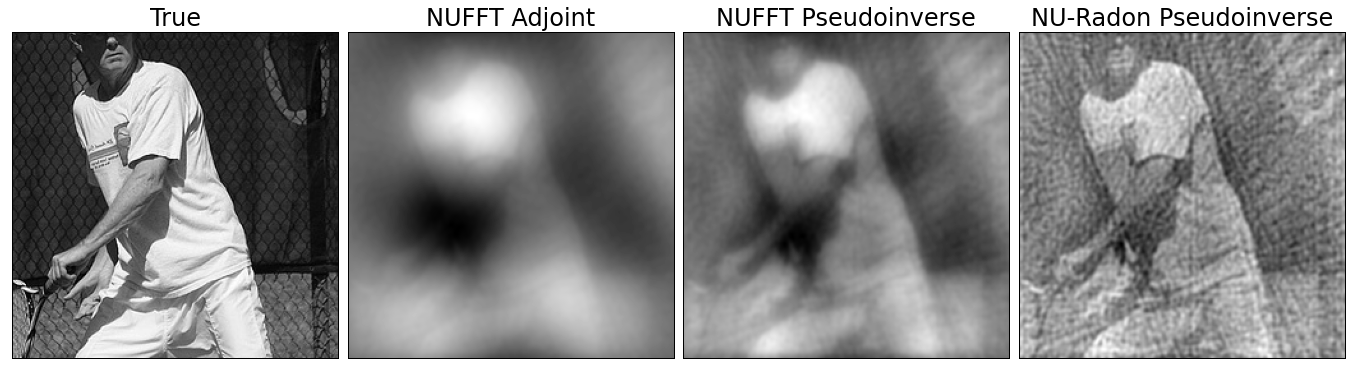

In [67]:
sns.set_context('paper', font_scale=2.5)
compare_multiple([x, x_dirty_nufft, x_dirty_nufft_dens, x_dirty_nufft_ramp], titles=["True", f"NUFFT Adjoint", f"NUFFT Pseudoinverse", f"NU-Radon Pseudoinverse"],  same_scale=False, colorbar=False, cmap='gray', PSNR=False)
plt.savefig("./plots/nufft_filtering_thesis.pdf")

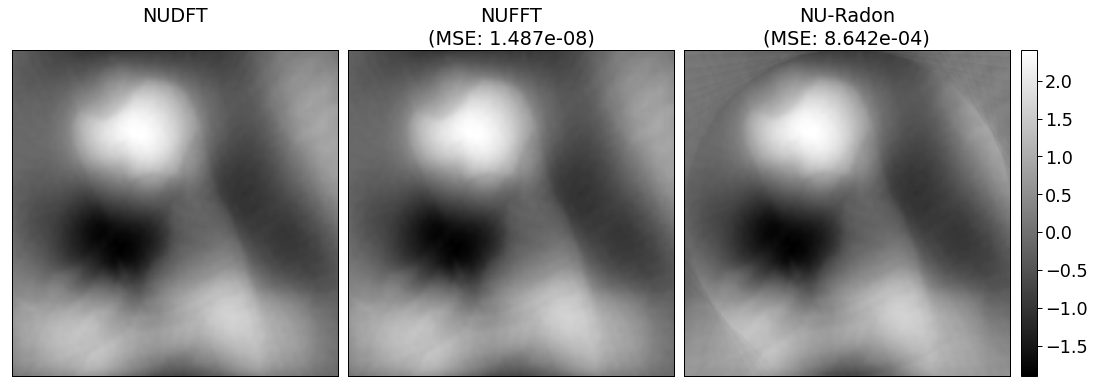

In [66]:
sns.set_context('paper', font_scale=2)
compare_multiple([x_dirty_dft.real, x_dirty_nufft.real, x_dirty_radon.real], titles=["NUDFT", f"NUFFT", f"NU-Radon"],  same_scale=False, colorbar=True, cmap='gray', PSNR=True)
plt.savefig("./plots/self_adjoint_all_new_thesis.pdf")
# plt.savefig("./plots/nufft_filtering2.pdf")